# Simple Checks

### import Libraries

In [1]:
import os
import json
import numpy as np
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow

I0000 00:00:1774933485.016448  148591 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774933485.016754  148591 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774933485.053392  148591 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1774933486.136701  148591 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774933486.136907  148591 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### check version of lib

In [2]:
import tensorflow as tf
print(tf.keras.__version__)

3.12.1


## simple code

In [3]:
import numpy as np
# Simple function f(x) = x^2
def f(x):
    return x ** 2

# Manual derivative (f’(x) = 2x)
def gradient(x):
    return 2 * x

# Update rule: x = x - learning_rate * gradient
x = 5.0
learning_rate = 0.1
for _ in range(10): # Manually optimize for 10 steps
    x -= learning_rate * gradient(x)
print(f"x: {x}, f(x): {f(x)}")

x: 0.5368709120000001, f(x): 0.2882303761517119


## gradients using keras

In [4]:
import tensorflow as tf

x = tf.Variable(5.0) # trainable variable
with tf.GradientTape() as tape: 
    y = x ** 2 # computes dy/dx automatically

grad = tape.gradient(y, x)
print(grad.numpy())

10.0


E0000 00:00:1774933487.045065  148591 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1774933487.045339  149113 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1774933487.063408  148591 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


# Building a simple fully connected neural network with keras

## Task 1: Data Preparation

### Loading and preprocessing data with PIL

In [5]:
img_width, img_height = 28, 28
train_dir = "/home/rokshh/Documents/college/sem6/ai-deep-learning/week-4/dataset/Train/"
test_dir = "/home/rokshh/Documents/college/sem6/ai-deep-learning/week-4/dataset/Test/"

def load_images_from_folder(folder: str):
    # os.listdir just gives list of dir, sorted sorts them, this is very imp
    class_names = sorted(os.listdir(folder)) 
    class_map = { name: i for i, name in enumerate(class_names) }

    images, labels = [], []
    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            img = Image.open(img_path).convert("L") # gray scale image
            img = img.resize((img_height, img_width)) # resize
            img = np.array(img) / 255.0 # normalize

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

### reshaping for compatibility

In [6]:
x_train = x_train.reshape(-1, img_width, img_height, 1)
x_test = x_test.reshape(-1, img_width, img_height, 1)

### converting labels to_categorical

In [7]:
# One-hot encode the labels (0-9) for classification
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

### print the shapes

In [8]:
# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


### visualize the data

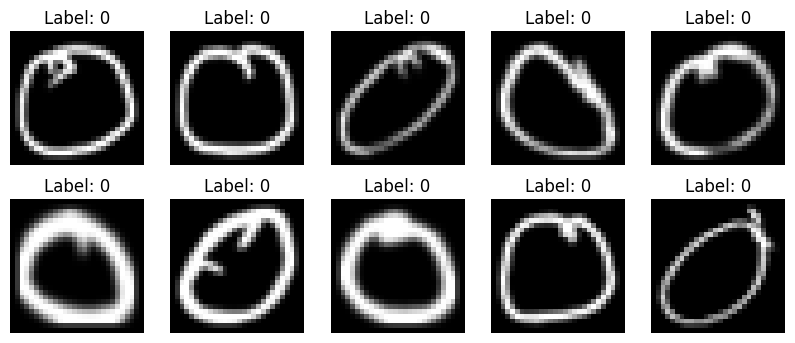

In [9]:
# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.show()

## Task 2: Build the FCN Model

### build the model

In [10]:
import tensorflow as tf
from tensorflow import keras

input_shape = (28, 28, 1)
num_classes = 10

model = keras.Sequential([
    keras.layers.Input(shape=input_shape),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"), #hidden layers
    keras.layers.Dense(num_classes, activation="softmax") #output layer
]) 

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

None


### functional api

In [11]:
def build_functional_model():
    inputs = tf.keras.Input(shape=input_shape)

    x = tf.keras.layers.Flatten()(inputs)
    x = tf.keras.layers.Dense(64, activation="sigmoid")(x)
    x = tf.keras.layers.Dense(128, activation="sigmoid")(x)
    x = tf.keras.layers.Dense(256, activation="sigmoid")(x)

    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

functional_model = build_functional_model()
functional_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3: Compile the Model

In [12]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

## Task 4: Train the Model

In [13]:
batch_size = 128
epochs = 20
validation_split = 0.2

# shuffle the data and take validation split or use validation_data
indices = np.random.permutation(len(x_train))
x_train = x_train[indices]
y_train = y_train[indices]

# make sure 
os.makedirs("model_checkpoints", exist_ok=True)

callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="./model_checkpoints/model_at_epoch_{epoch}.keras"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4)
]

history = model.fit(
    x=x_train,
    y=y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=validation_split,
    callbacks=callbacks,
    verbose=0
)

print(history.history.keys())
print(json.dumps(history.history, indent=2))

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
{
  "accuracy": [
    0.42073529958724976,
    0.8165441155433655,
    0.8956617712974548,
    0.932941198348999,
    0.9513970613479614,
    0.9609558582305908,
    0.9661029577255249,
    0.9735293984413147,
    0.9778676629066467,
    0.981176495552063,
    0.9844117760658264,
    0.9882352948188782,
    0.9900735020637512,
    0.9924264550209045,
    0.9934558868408203,
    0.9943382143974304,
    0.9950735569000244,
    0.9969117641448975,
    0.9971323609352112,
    0.9975735545158386
  ],
  "loss": [
    1.8723536729812622,
    0.6623068451881409,
    0.3511296510696411,
    0.24053794145584106,
    0.1812921166419983,
    0.14286352694034576,
    0.11871641129255295,
    0.09918879717588425,
    0.08298508822917938,
    0.06989137083292007,
    0.06054623797535896,
    0.051384855061769485,
    0.0443265363574028,
    0.037577562034130096,
    0.0330885574221611,
    0.028421388939023018,
    0.02423417940735817,
    0

## Task 5: Evaluate the Model

In [14]:
loss, accuracy = model.evaluate(
    x=x_test,
    y=y_test, 
    batch_size=batch_size, 
    verbose=0, 
)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.0800
Test Accuracy: 0.9767


## Task 6: Save and Load the Model

In [15]:
model.save('fully_connected_neural_network_devanagari.h5')
loaded_model = tf.keras.models.load_model('fully_connected_neural_network_devanagari.h5')

## Task 7: Predictions

In [16]:
# Predict on test data
predictions = loaded_model.predict(x_test, verbose=0)

# Convert predictions from probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)

# Check the first prediction
print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {np.argmax(y_test[0])}")

Predicted label for first image: 0
True label for first image: 0


## Task 8: Visualization

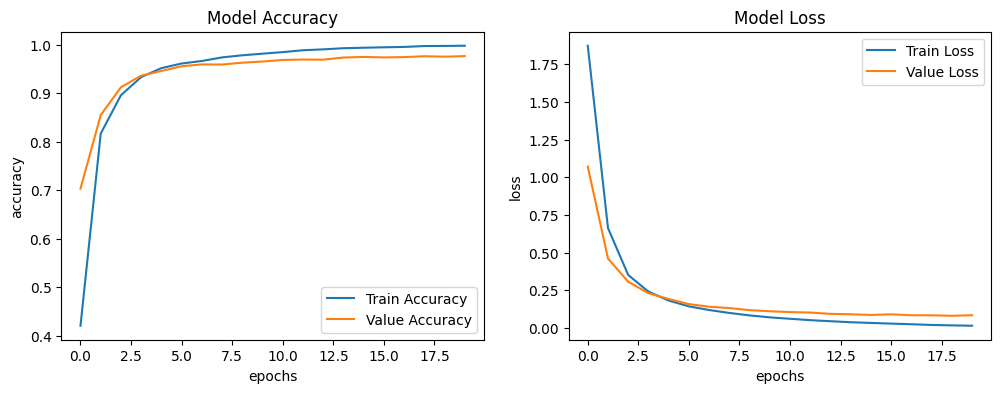

In [17]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Value Accuracy")
plt.title("Model Accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Value Loss")
plt.title("Model Loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()

plt.show()